# Clasificación Predictiva en Enfermedad de Alzheimer

<img src="https://cdn-icons-png.flaticon.com/512/5635/5635722.png" width="200">

Autor: **Javier Gonzalez Sanabria**, PhD.

Role target: Data Scientist, Jr.

Proyecto de Machine Learning aplicado a Healthcare / Life Sciences (Proyecto formativo y de portfolio personal)

Objetivo: desarrollar un modelo de clasificación interpretable como ejercicio aplicado de formación en Data Science, orientado a simular un escenario realista de priorización clínica de pacientes con riesgo de enfermedad de Alzheimer. El foco del análisis está puesto en la claridad conceptual, la correcta formulación del problema, la interpretabilidad del modelo y la adopción de buenas prácticas reproducibles, más que en la optimización extrema del rendimiento predictivo.

## 0. Setup y contexto del proyecto

### 0.1 Librerías y configuración del entorno

En este proyecto se utilizarán librerías estándar del ecosistema Python para análisis de datos y Machine Learning, priorizando herramientas ampliamente adoptadas en entornos profesionales y clínicos.

- Manipulación de datos: **pandas, numpy**

- Visualización: **matplotlib, seaborn**

- Machine Learning: **scikit-learn**

### 0.2 Reproducibilidad

Dado que el proyecto tiene un objetivo formativo y de portfolio, se establece una **semilla aleatoria fija** para garantizar que los resultados obtenidos puedan ser reproducidos.

### 0.3 Contexto clínico y objetivo del modelo

- Problema clínico

  La enfermedad de Alzheimer representa la principal causa de deterioro cognitivo (demencia) en adultos mayores a nivel mundial. En contextos clínicos reales, la detección temprana y la correcta priorización de pacientes para evaluaciones especializadas constituyen un desafío relevante, especialmente cuando los recursos diagnósticos son limitados.

  Este proyecto plantea un escenario simplificado en el que se dispone de información demográfica, clínica, funcional y cognitiva de pacientes, con el objetivo de estimar la **probabilidad de diagnóstico de enfermedad de Alzheimer**.

- Rol del modelo

  El modelo desarrollado en este notebook no tiene como finalidad realizar un diagnóstico clínico, sino funciona como una herramienta de **decision support**.
  Tiene como proposito poder apoyar la priorización de pacientes con mayor riesgo. Además, busca ilustrar cómo modelos de Machine Learning pueden integrarse como soporte a la toma de decisiones clínicas.

- Alcance y limitaciones

  Este análisis se basa en un dataset secundario de origen público (Kaggle), sin validación externa. Los resultados no son generalizables a poblaciones reales sin un proceso formal de validación clínica.
  El foco de este proyecto está en la metodología, interpretabilidad y narrativa técnica, no en la optimización extrema del rendimiento predictivo.

## 1. Descripción del dataset

### 1.1 Origen del dataset

El dataset utilizado en este proyecto corresponde al Alzheimer’s Disease Dataset, publicado por *Rabie El Kharoua* en Kaggle (2024).

Se trata de un dataset sintético/curado con fines educativos, que simula información clínica y demográfica de pacientes evaluados por posible enfermedad de Alzheimer.

El uso de este tipo de datasets es habitual en contextos formativos, ya que permite trabajar con variables clínicamente plausibles sin implicar datos sensibles reales.

### 1.2 Descripción general de las variables

El dataset incluye variables que pueden agruparse en las siguientes categorías conceptuales:

- Factores demográficos: Variables como edad y sexo, que actúan como moduladores de riesgo y contexto clínico.

- Estilo de vida: Información relacionada con hábitos que pueden influir indirectamente en la salud cognitiva.

- Historia médica: Variables asociadas a antecedentes clínicos relevantes, particularmente aquellos vinculados a riesgo cardiovascular y metabólico.

- Mediciones clínicas: Incluyen parámetros como BMI, presión arterial y colesterol, utilizados como indicadores de estado general de salud.

- Evaluaciones cognitivas y funcionales: Puntajes derivados de pruebas estandarizadas (por ejemplo, MMSE y evaluaciones funcionales), que reflejan de manera directa el estado cognitivo y la capacidad funcional del paciente.

Desde una perspectiva clínica, este último grupo constituye el núcleo informativo más cercano al fenotipo de la enfermedad.

### 1.3 Variable objetivo

La variable objetivo del análisis es **Diagnosis**, una variable binaria que indica la presencia (1) o ausencia (0) de diagnóstico de enfermedad de Alzheimer.

### 1.4 Supuestos y advertencias clínicas

Tener en cuenta para evitar extrapolaciones inapropiadas y para mantener una comunicación responsable en contextos de salud, que:

- El dataset no representa una cohorte clínica real ni un estudio epidemiológico validado.

- Las relaciones entre variables pueden no reflejar completamente la complejidad biológica y clínica de la enfermedad de Alzheimer.

- Los resultados obtenidos deben interpretarse exclusivamente en el marco de un ejercicio formativo.

## 2. Carga de datos y exploración inicial

### 2.1 Carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Agregamos la carpeta src al path para importar los módulos
sys.path.insert(0, os.path.abspath('..'))

# Importamos los módulos del proyecto
from src import utils, plotting, data_processing, evaluation, modeling

# Configuración estética
utils.setup_theme()

# Ruta local al archivo CSV
data_path = "../data/alzheimers_disease_data.csv"

# Carga del dataset
df = data_processing.load_alzheimer_data(data_path)

# Inspección inicial
df.head(20)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
5,4756,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,...,0,0,9.015686,1,0,0,0,0,0,XXXConfid
6,4757,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,...,0,0,9.236328,0,0,0,0,1,0,XXXConfid
7,4758,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,...,0,0,4.517248,1,0,0,0,1,1,XXXConfid
8,4759,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,...,0,1,0.756232,0,0,1,0,0,0,XXXConfid
9,4760,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,...,0,1,4.554394,0,0,0,0,0,0,XXXConfid


### 2.2 Dimensiones y tipos de datos

In [2]:
# Dimensiones del dataset
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

# Información general del dataset
df.info()

Número de observaciones: 2149
Número de variables: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  

### 2.3 Valores faltantes

In [3]:
# Dimensiones del dataset
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

# Información general del dataset
df.info()


Número de observaciones: 2149
Número de variables: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  

### 2.4 Distribución del target

Es necesario evaluar posible desbalance de clases en la variable target Diagnosis, ya que puede sesgar métricas de performance del modelo.

In [4]:
# Análisis de valores faltantes
missing_summary = data_processing.analyze_missing_values(df)
display(missing_summary)


,missing_count,missing_percentage
PatientID,0,0.0
Age,0,0.0
Gender,0,0.0
Ethnicity,0,0.0
EducationLevel,0,0.0
BMI,0,0.0
Smoking,0,0.0
AlcoholConsumption,0,0.0
PhysicalActivity,0,0.0
DietQuality,0,0.0


La variable *target* presenta un desbalance moderado, **2/3 : 1/3** respecto del diagnostico **negativo : positivo**. Esto es consistente con escenarios de screening clínico en Alzheimer. Por esto, vamos a priorizar métricas robustas al desbalance y evaluaremos el desempeño del modelo más allá del *accuracy*, evitando técnicas de balanceo artificial en etapas tempranas.

## 3. EDA orientado a clínica

En esta sección realizaremos un análisis exploratorio de las variables clínicas con mayor poder discriminatorio para el diagnóstico de Alzheimer. Al ser una patología caracterizada por el deterioro progresivo, es fundamental evaluar la relación entre la **edad** y el **rendimiento en pruebas estandarizadas**.

Nos centraremos en tres dimensiones críticas: el MMSE (Mini-Mental State Examination) como medida de estado cognitivo global, el Functional Assessment para evaluar el desempeño en tareas complejas, y el ADL (Activities of Daily Living) como indicador de autonomía funcional. Estas variables continuas permiten observar gradientes de deterioro que variables tabulares binarias (como Memory Complaints o Behavioral Problems) no logran capturar con la misma resolución estadística.

### 3.1 Variables cognitivas y funcionales vs diagnóstico


In [5]:
# Conteo y distribución del target
target_distribution = data_processing.analyze_target_distribution(df)
display(target_distribution)


,count,percentage
Diagnosis,,
0,1389,64.634714
1,760,35.365286


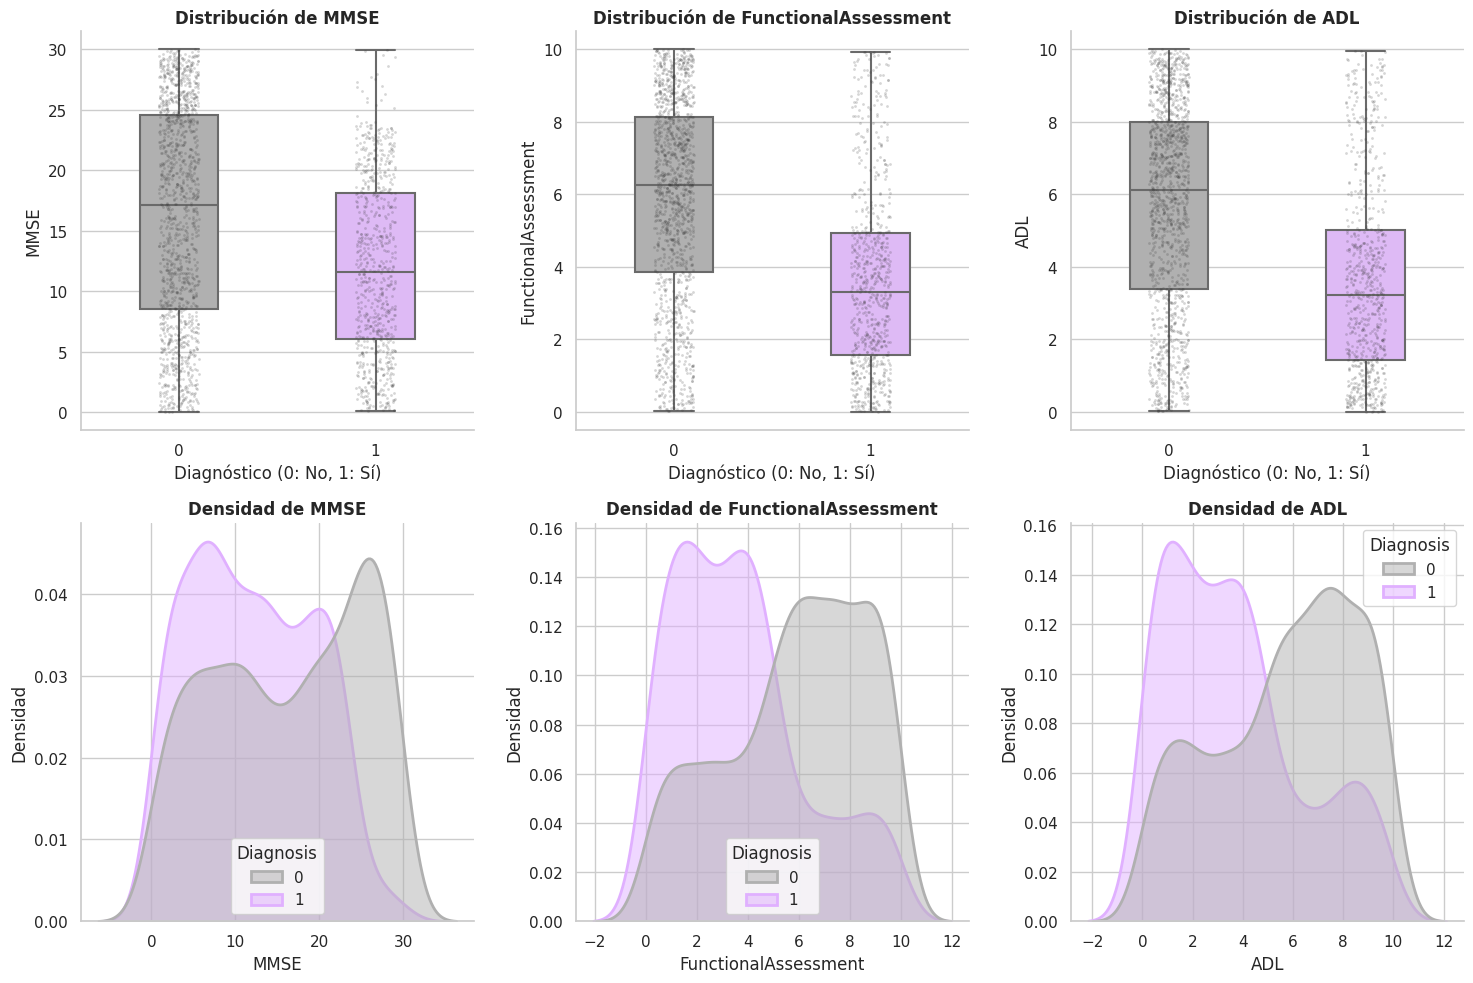

In [6]:
cognitive_features = ["MMSE", "FunctionalAssessment", "ADL"]
plotting.plot_cognitive_features(df, cognitive_features)


Se puede observar que las metricas cognitivas exploradas presentan buena separacion de las distribuciones de diagnostico, volviendo a estas variables como potenciales discriminantes del diagnostico.

### 3.2 Edad vs diagnóstico

En el Alzheimer es esperable que a mayor Edad los pacientes muestren un mayor grado de deterioro cognitivo. Pero esta variable puede ser considerada como factor de riesgo para es diagnostico pero con poco poder predictivo para nuestro modelo.

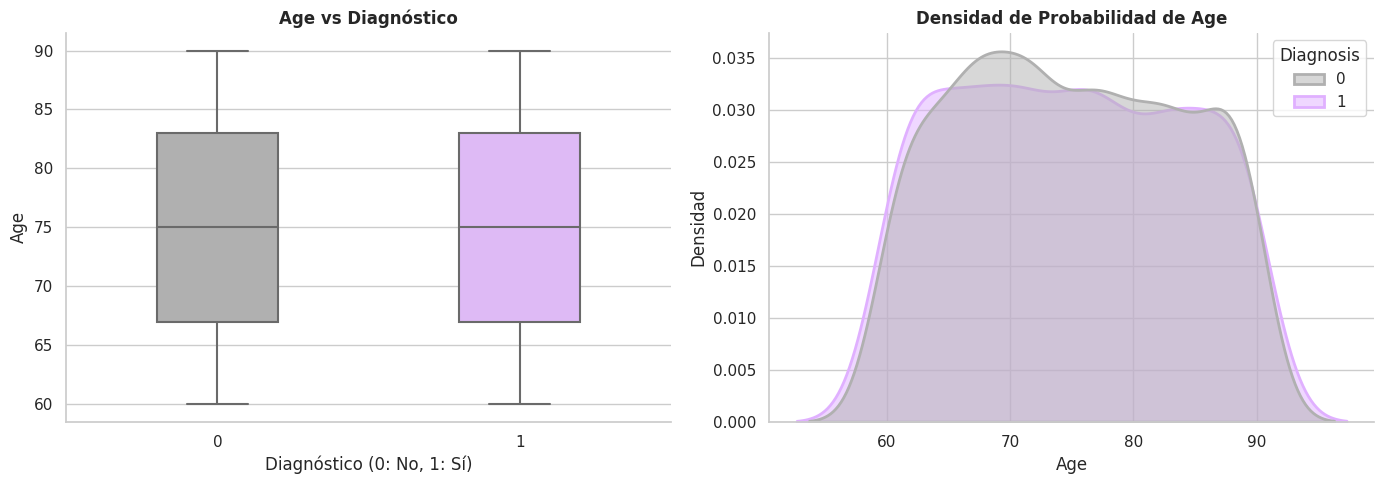

In [7]:
plotting.plot_continuous_comparison(df, "Age")

Podemos ver que la edad por si sola no presenta un umbral etario que separe los grupos de diagnostico. Es posible decir que el riesgo aumenta con la edad a nivel poblacional, pero no es predictivo a nivel individual. Esta variable no la vamos a descartar sino que vamos a considerarla pero no como un feature dominante en la pedicción del modelo diagnostico.

### 3.3 Variables clínicas y de estilo de vida

Las variables clínicas y de estilo de vida son clave en Alzheimer porque son factores de riesgo modificables que promueven la patología β-amiloide y vascular, permiten predecir el riesgo años antes y orientan intervenciones para retrasar o prevenir hasta un 45% de casos.

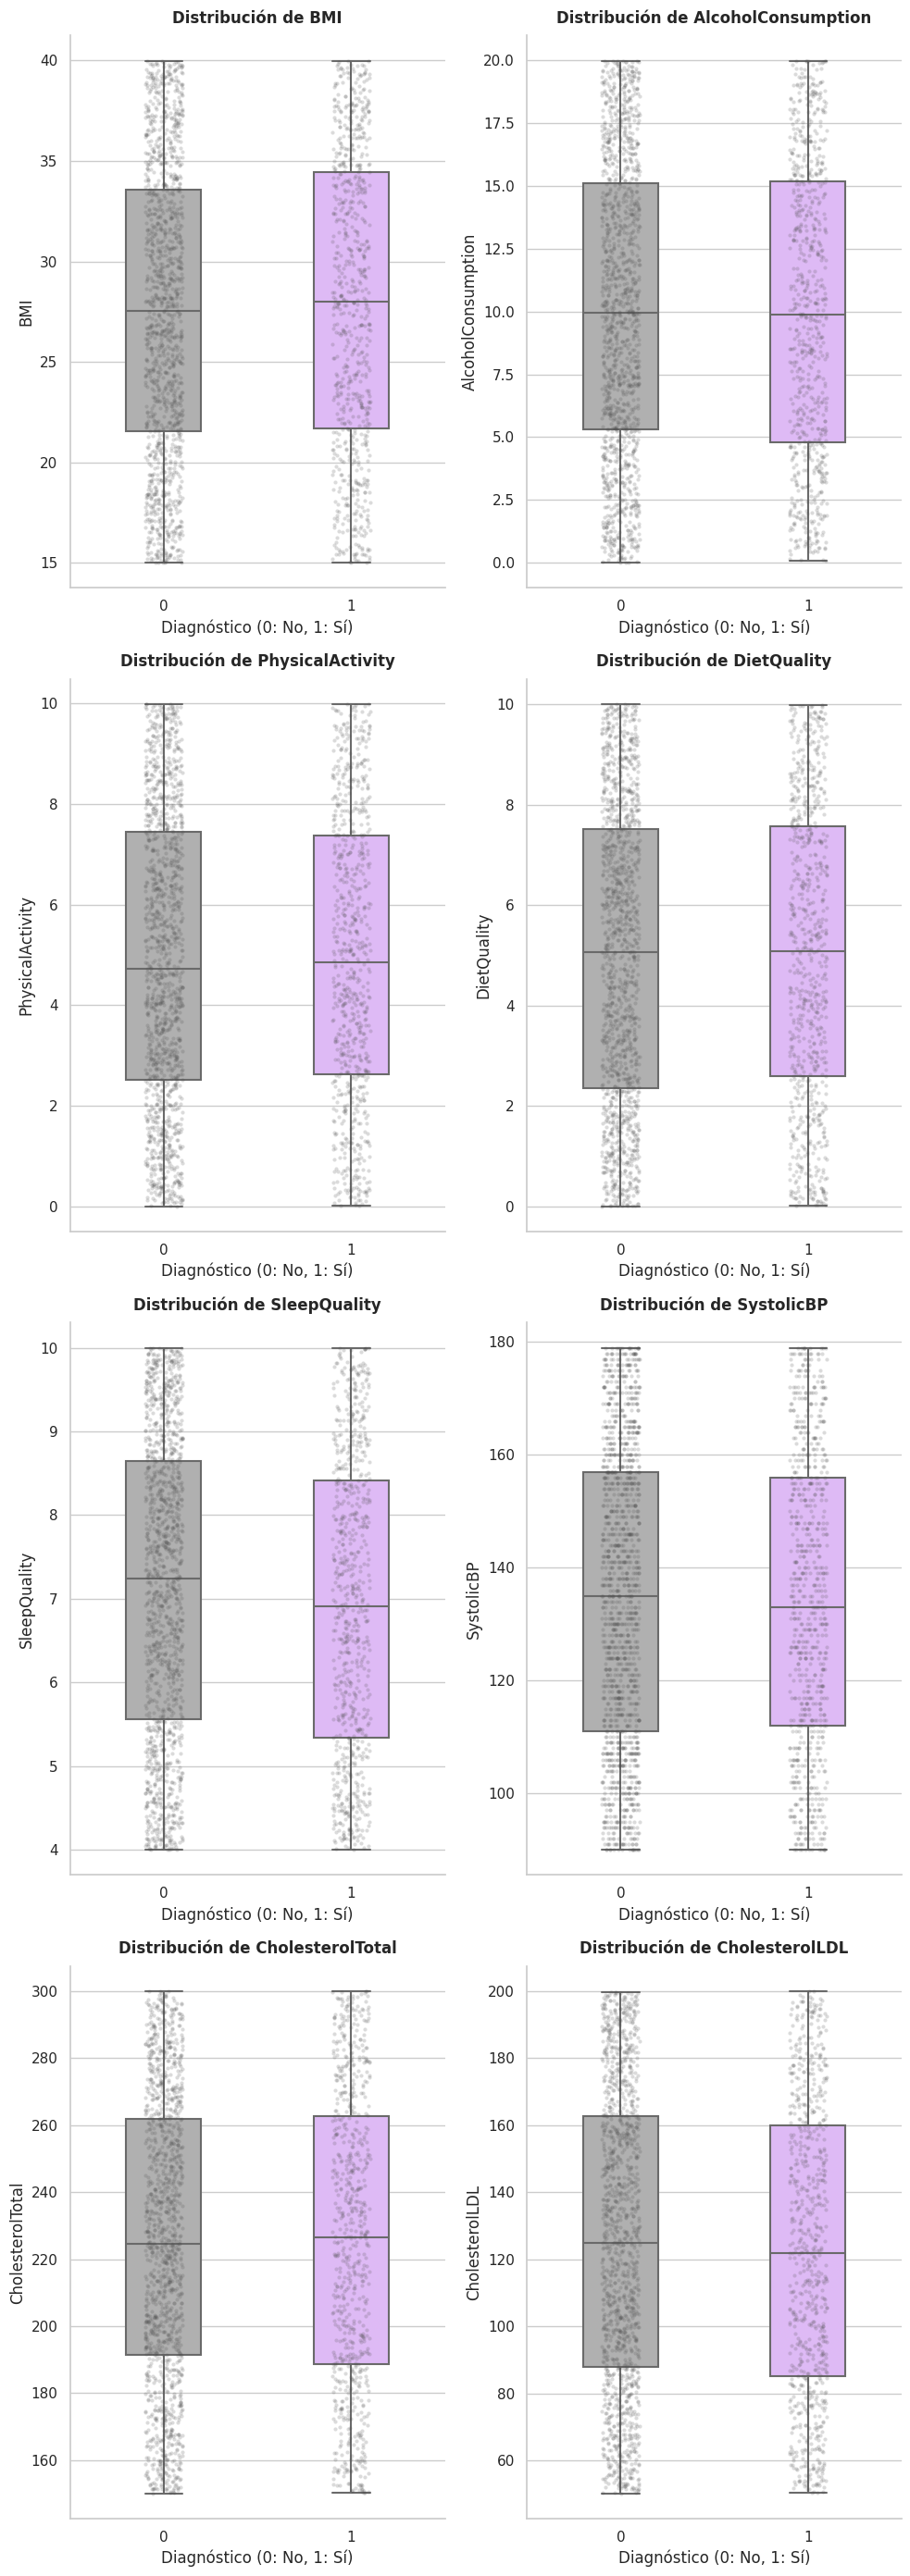

In [8]:
clinical_vars = [
    "BMI", "AlcoholConsumption", "PhysicalActivity",
    "DietQuality", "SleepQuality", "SystolicBP",
    "CholesterolTotal", "CholesterolLDL"
]

plotting.plot_clinical_features_grid(df, clinical_vars)


En nuestro dataset podemos ver que las variables clínicas y de estilo de vida no muestran capacidad discriminatoria del diagnostico cuando se consideran de forma aislada. Sin embargo, se mantendrán en el modelo como posibles moduladores de riesgo, evaluando su contribución mediante regularización y análisis de importancia de variables.

### 3.4 Análisis de variables binarias (antecedentes médicos y sintomatología cognitiva/conductual)

Definimos una funcion auxiliar para poder evaluar cual es la prevalencia de las metricas respecto del diagnostico de Alzheimer:

In [9]:
# Descomentar para ver la función auxiliar utilizada
# La función binary_proportion_summary está disponible en src.data_processing.analyze_binary_prevalence()

# Ejemplo de uso:
# summary = data_processing.analyze_binary_prevalence(df, variables)

#### 3.4.1 Antecedentes médicos

In [10]:
medical_history_vars = [
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression"
]

medical_history_summary = data_processing.analyze_binary_prevalence(df, medical_history_vars)
display(medical_history_summary.style.format(precision=2).background_gradient(subset=['Dif_Absoluta'], cmap='Purples'))


,Variable,% en Diag. Negativo,% en Diag. Positivo,Dif_Absoluta
1,CardiovascularDisease,13.61,15.92,2.31
3,Depression,20.23,19.74,-0.49
2,Diabetes,15.91,13.55,-2.36
0,FamilyHistoryAlzheimers,26.28,23.29,-2.99


La tabla muestra la prevalencia de antecedentes por grupo diagnóstico. Los pacientes con Alzheimer exhiben +2,31 % más enfermedades cardiovasculares (coherente con el rol vascular en la patología). Sorprendentemente, el grupo sin diagnóstico presenta mayor prevalencia de antecedentes familiares de Alzheimer, resultado contraintuitivo que podría deberse a **sesgos en los datos** (subdiagnóstico, sesgo de selección o mayor vigilancia en familias afectadas).

#### 3.4.2 Sintomatología cognitiva y conductual

In [11]:
symptom_vars = [
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness",
    "MemoryComplaints",
    "BehavioralProblems"
]

symptom_vars_summary = data_processing.analyze_binary_prevalence(df, symptom_vars)
display(symptom_vars_summary.style.format(precision=2).background_gradient(subset=['Dif_Absoluta'], cmap='Purples'))


,Variable,% en Diag. Negativo,% en Diag. Positivo,Dif_Absoluta
5,MemoryComplaints,11.59,37.63,26.04
6,BehavioralProblems,9.65,26.71,17.06
3,DifficultyCompletingTasks,15.62,16.32,0.69
4,Forgetfulness,30.17,30.13,-0.03
2,PersonalityChanges,15.62,14.08,-1.54
0,Confusion,21.09,19.47,-1.62
1,Disorientation,16.49,14.61,-1.88


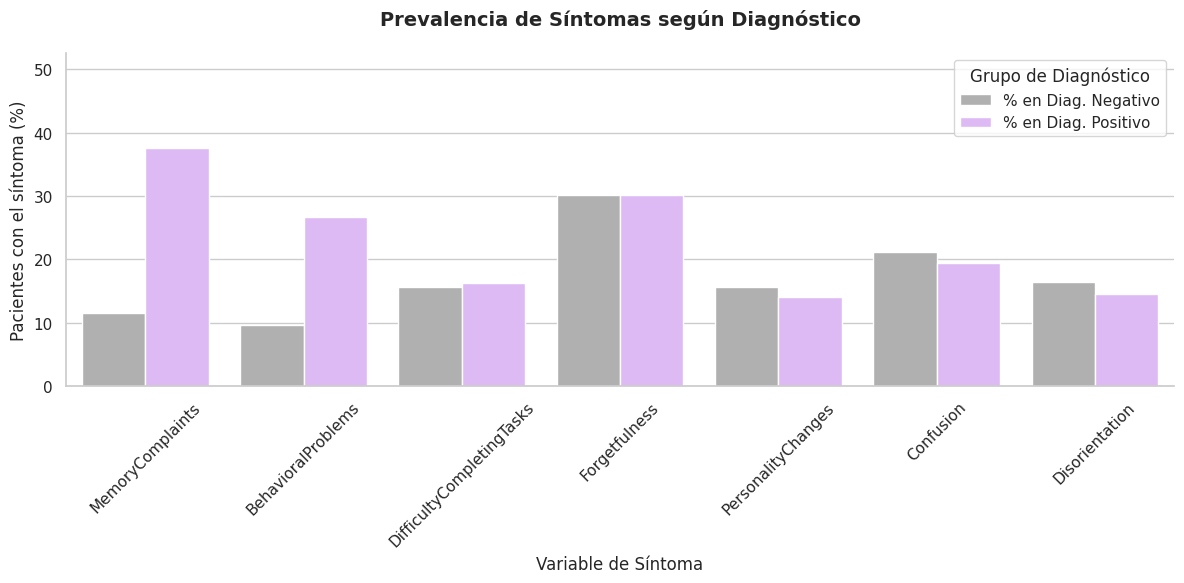

In [12]:
plotting.plot_binary_symptoms_prevalence(symptom_vars_summary)

Contrario a la expectativa clínica, síntomas cardinales como Confusion y Disorientation presentan una prevalencia ligeramente mayor en el grupo sin diagnóstico. Esta inversión de la tendencia sugiere que, en este dataset, estos síntomas actúan como fuentes de ruido, posiblemente por solapamiento con otras condiciones (depresión, delirium o deterioro cognitivo leve no progresivo).

En contraste, otras variables sí exhiben separaciones claras y clínicamente relevantes. Tanto las quejas subjetivas de memoria (**MemoryComplaints**) como los problemas conductuales (**BehavioralProblems**) muestran diferencias absolutas significativas a favor del grupo positivo, alineándose con la literatura que asocia estos dominios al deterioro en Alzheimer (alteraciones conductuales como agitación, apatía, irritabilidad o síntomas neuropsiquiátricos aparecen frecuentemente en etapas moderadas-avanzadas).

### 3.5 Correlaciones y redundancia entre variables

Dado el resultado previo (síntomas binarios con comportamiento ruidoso), esta sección no busca descubrir señal nueva, sino detectar redundancia, colinealidad y proxies clínicos antes del modelado.

#### 3.5.1 Correlaciones entre métricas cognitivas y funcionales

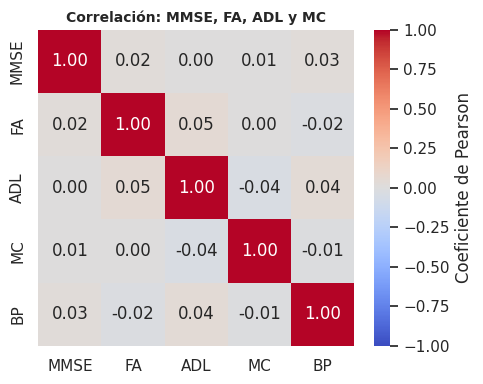

In [13]:
cognitive_vars = ["MMSE", "FunctionalAssessment", "ADL", "MemoryComplaints", "BehavioralProblems"]
corr_cognitive = df[cognitive_vars].corr()

short_names = {
    "MMSE": "MMSE",
    "FunctionalAssessment": "FA",
    "ADL": "ADL",
    "MemoryComplaints": "MC",
    "BehavioralProblems": "BP"
}

plotting.plot_correlation_heatmap(corr_cognitive, short_names, "Correlación: MMSE, FA, ADL y MC")


La matriz de correlación revela una independencia casi absoluta entre estas variables: $r < abs(0.05$). Desde un punto de vista analítico, esto es altamente positivo para el modelado, ya que garantiza la ausencia de multicolinealidad. Sin embargo, desde una perspectiva clínica, es un hallazgo atípico que sugiere que el deterioro en este grupo de datos no sigue un patrón lineal uniforme entre cognición y funcionalidad.

#### 3.5.2 Correlaciones dentro de mediciones clínicas

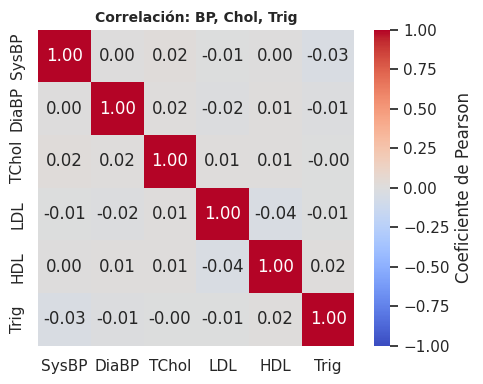

In [14]:
clinical_measurements = [
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides"
]

corr_clinical = df[clinical_measurements].corr()

short_names = {
    "SystolicBP": "SysBP",
    "DiastolicBP": "DiaBP",
    "CholesterolTotal": "TChol",
    "CholesterolLDL": "LDL",
    "CholesterolHDL": "HDL",
    "CholesterolTriglycerides": "Trig"
}

plotting.plot_correlation_heatmap(corr_clinical, short_names, "Correlación: BP, Chol, Trig")

El análisis de correlaciones entre predictores muestra relaciones mayormente débiles, sin evidencia de multicolinealidad significativa. Esto sugiere que las variables aportan información complementaria y que no es necesario realizar una selección agresiva de features en esta etapa. En consecuencia, se optará por estrategias de modelado que permitan manejar posibles interacciones entre variables, evaluando tanto enfoques lineales interpretables como modelos más flexibles, comparando su desempeño de forma empírica.


## 4. Preparación de datos

A partir del EDA se identificaron variables con alto poder discriminante, en particular las métricas funcionales y cognitivas validadas (MMSE, ADL, FunctionalAssessment), así como algunas variables binarias asociadas a dominios clínicamente relevantes, como las quejas subjetivas de memoria (MemoryComplaints) y los problemas conductuales (BehavioralProblems).

Sin embargo, para evitar un sesgo de selección prematuro, no se excluyen a priori otras variables binarias que mostraron bajo o nulo poder discriminante en el análisis exploratorio (por ejemplo, Confusion o Disorientation). En su lugar, se adopta una estrategia conservadora en la que el modelo es el encargado de determinar qué variables aportan señal predictiva real, mediante regularización y análisis posterior de importancia.

### 4.1 Definición de variable objetivo



In [15]:
# Definición de features y target
numeric_features = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

binary_features = [
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression",
    "HeadInjury",
    "Hypertension",
    "MemoryComplaints",
    "BehavioralProblems",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness"
]

selected_features = numeric_features + binary_features

target = "Diagnosis"

X, y = data_processing.prepare_features_and_target(df, selected_features, target)


### 4.2 Identificación de tipos de variables

In [16]:
X = df[selected_features] # corrección X eliminando iDs

X.head()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,...,Depression,HeadInjury,Hypertension,MemoryComplaints,BehavioralProblems,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,73,22.927749,13.297218,6.327112,1.347214,9.025679,142,72,242.366840,56.150897,...,1,0,0,0,0,0,0,0,1,0
1,89,26.827681,4.542524,7.619885,0.518767,7.151293,115,64,231.162595,193.407996,...,0,0,0,0,0,0,0,0,0,1
2,73,17.795882,19.555085,7.844988,1.826335,9.673574,99,116,284.181858,153.322762,...,0,0,0,0,0,0,1,0,1,0
3,74,33.800817,12.209266,8.428001,7.435604,8.392554,118,115,159.582240,65.366637,...,0,0,0,0,1,0,0,0,0,0
4,89,20.716974,18.454356,6.310461,0.795498,5.597238,94,117,237.602184,92.869700,...,0,0,0,0,0,0,0,1,1,0


### 4.3 Split train–test

In [17]:
# Split train-test (estratificado)
X_train, X_test, y_train, y_test = data_processing.split_train_test(X, y)

### 4.4 Escalado de variables numéricas

In [18]:
# Escalado de variables numéricas
X_train_scaled, X_test_scaled, scaler = data_processing.scale_numeric_features(
    X_train, X_test, numeric_features
)

En esta etapa se preparó el dataset para el modelado predictivo, separando explícitamente la variable objetivo (Diagnosis), preservando la prevalencia del diagnóstico mediante un split estratificado y aplicando escalado únicamente a variables continuas. No se realizaron transformaciones complejas ni selección agresiva de features, priorizando interpretabilidad, reproducibilidad y control metodológico. El manejo del desbalance se abordará durante la etapa de entrenamiento y evaluación de modelos.

## 5. Modelado Baseline (Regresión Logística regularizada)

Como punto de partida, se implementa una **Regresión Logística** como modelo de referencia (baseline). Este enfoque es ampliamente utilizado en analítica clínica debido a su interpretabilidad, estabilidad y facilidad de validación.

La incorporación de regularización L2 (Ridge) permite controlar la magnitud de los coeficientes, reducir el impacto de posibles redundancias entre predictores y minimizar el riesgo de overfitting.

Además, la regresión logística facilita el análisis de probabilidades predichas y de los trade-offs entre sensibilidad y precisión, estableciendo una base sólida y transparente para comparar el desempeño y el valor agregado de modelos más flexibles en etapas posteriores.

### 5.1 Entrenamiento del modelo

In [19]:
# Entrenamiento del modelo baseline
log_reg = modeling.train_logistic_regression(X_train_scaled, y_train)

### 5.3 Predicción y probabilidades

In [20]:
# Predicción y probabilidades
y_pred, y_proba = evaluation.get_predictions_and_probabilities(log_reg, X_test_scaled)

### 5.4 Métricas de performance del modelo

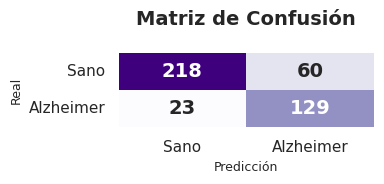


REPORTES DE CLASIFICACIÓN
              precision    recall  f1-score   support

        Sano       0.90      0.78      0.84       278
   Alzheimer       0.68      0.85      0.76       152

    accuracy                           0.81       430
   macro avg       0.79      0.82      0.80       430
weighted avg       0.83      0.81      0.81       430



In [21]:
# Matriz de confusión
cm = evaluation.get_confusion_matrix(y_test, y_pred)
plotting.plot_confusion_matrix(cm)

# Reporte de clasificación
evaluation.print_classification_report(y_test, y_pred)

El modelo presenta un 0.85 de recall y un 0.68 de precisión. Es fundamental en el contexto de un modelo predictivo de diagnostico optimizar el recall por encima de la precisión de manera de reducir los falsos negativos (riego alto de perder pacientes enfermos con la posibilidad de privarlos de tratamiento a tiempo).

### 5.5 Curva ROC (AUC)

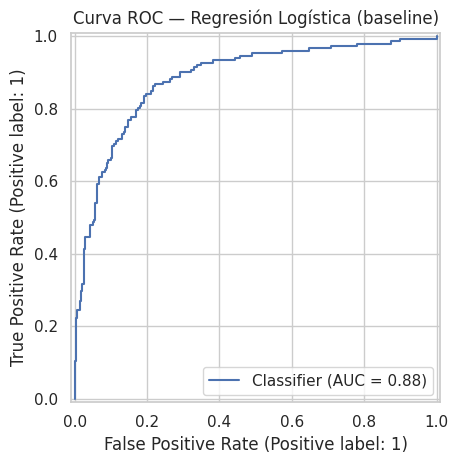

ROC AUC Score: 0.884


In [22]:
# Curva ROC
evaluation.plot_roc_curve(y_test, y_proba, "Curva ROC — Regresión Logística (baseline)")
roc_auc = evaluation.get_roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {roc_auc:.3f}")

### 5.6 Interpretación de coeficientes (Regresión Logística)

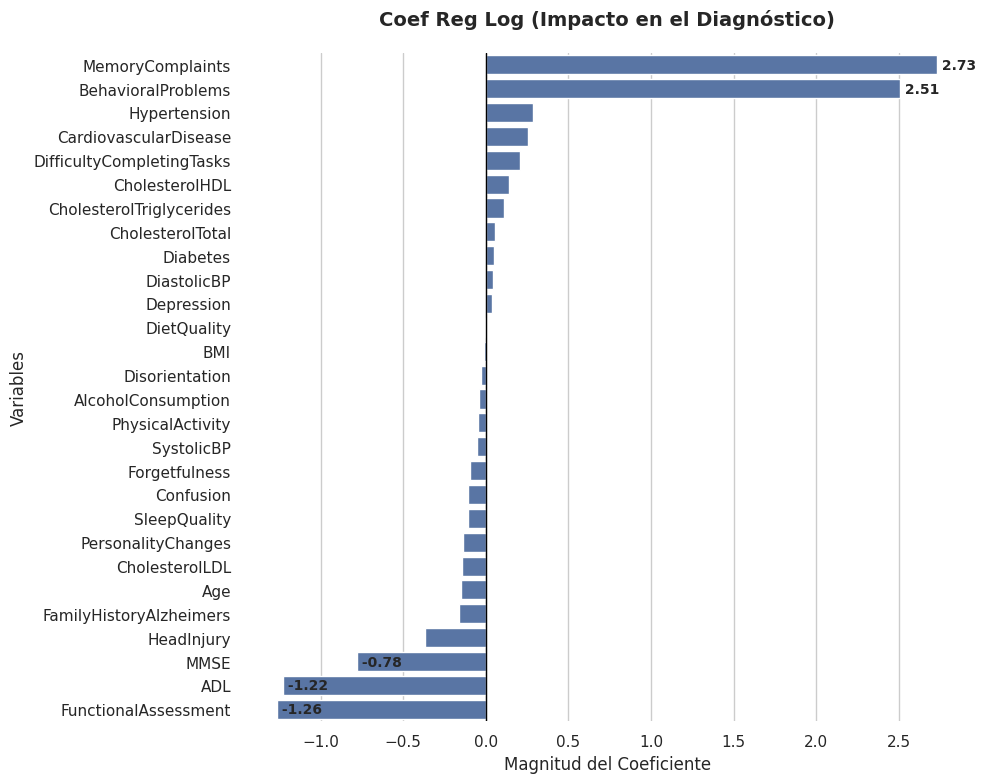

,Feature,Coefficient
21,MemoryComplaints,2.731634
22,BehavioralProblems,2.509959
20,Hypertension,0.283287
16,CardiovascularDisease,0.256437
26,DifficultyCompletingTasks,0.210267
10,CholesterolHDL,0.139554
11,CholesterolTriglycerides,0.109759
8,CholesterolTotal,0.056749
17,Diabetes,0.052897
7,DiastolicBP,0.046773


In [23]:
# Coeficientes del modelo de Regresión Logística
coef_df = evaluation.get_logistic_regression_coefficients(log_reg, X_train_scaled.columns)
plotting.plot_model_coefficients(coef_df, "Coef Reg Log (Impacto en el Diagnóstico)")
display(coef_df)

La regresión logística permite interpretar directamente la dirección y magnitud relativa del efecto de cada variable sobre el **log-odds** de diagnóstico de Alzheimer.

#### 5.6.1. Factores asociados a mayor riesgo (coeficientes positivos)
- **MemoryComplaints** (2.73) → el predictor más fuerte  
- **BehavioralProblems** (2.51) → muy cercano en magnitud  

Ambos inclinan fuertemente la predicción hacia Alzheimer.  
Consistente con literatura (tanto quejas subjetivas de memoria y síntomas neuropsiquiátricos suelen ser señales tempranas).

#### 5.6.2. Indicadores de preservación cognitiva/funcional (coeficientes negativos)
- **FunctionalAssessment** (−1.26)  
- **ADL** (−1.22)  
- **MMSE** (−0.78)  

Puntuaciones más altas en estas escalas reducen marcadamente la probabilidad predicha de Alzheimer (menor riesgo diagnóstico y no necesariamente causalidad protectora).

## 6. Modelo no lineal — Random Forest

Tras establecer un baseline interpretable mediante Regresión Logística, se implementa Random Forest como el siguiente paso en nuestra jerarquía de modelado. El objetivo no es simplemente maximizar métricas de rendimiento, sino realizar un diagnóstico técnico de la estructura del dataset:

-  **Detección de Interacciones Complejas**: Capturar interacciones de alto orden (por ejemplo: ¿cómo afecta la Edad al riesgo si el MMSE ya está en niveles críticos?).

- **Robustez ante No-Linealidad**: Dado que en el análisis exploratorio (EDA) observamos una independencia estadística inusual entre predictores ($r < 0.05$), este modelo nos permitirá verificar si existe una señal predictiva latente que solo emerge mediante reglas de decisión no lineales.

- **Balance entre Poder y Explicabilidad**: Random Forest mantiene una excelente capacidad de generalización y nos ofrece herramientas de Feature Importance, fundamentales para validar si la jerarquía de importancia clínica (MemoryComplaints vs. Métricas Funcionales) se mantiene bajo un paradigma no lineal.


Justifica complejizar el modelo?: Existe una ganancia predictiva significativa al permitir que el modelo aprenda patrones no aditivos entre los factores clínicos, cognitivos y de estilo de vida?

### 6.1 Preparación de datos y modelo

- No se requiere escalado de variables.

- Se utilizan las mismas features seleccionadas

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

Justificación de hiperparametros

**n_estimators** = 300, suficiente para estabilizar importancias.

**min_samples_leaf** = 5, reduce sobreajuste en nodos pequeños.

**class_weight** = "balanced", compensa el desbalance moderado del target.

**random_state**: garantiza reproducibilidad.

### 6.2 Entrenamiento del modelo

In [25]:
# Entrenamiento del Random Forest
rf_model = modeling.train_random_forest(X_train, y_train)

### 6.3 Evaluación del modelo

In [26]:
# Evaluación completa del modelo Random Forest
results_rf = evaluation.evaluate_model(rf_model, X_test, y_test, "Random Forest")


            MÉTRICAS DE DESEMPEÑO: RANDOM FOREST            

REPORTES DE CLASIFICACIÓN
              precision    recall  f1-score   support

        Sano       0.95      0.97      0.96       278
   Alzheimer       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430

------------------------------------------------------------
            Métricas de Área bajo la Curva (AUC)            
------------------------------------------------------------
ROC AUC Score:                             0.9421
PR AUC Score (Average Precision):               0.9205


### 6.4 Validación Cruzada del Random Forest

Implementamos la Validación Cruzada (K-Fold) para garantizar que el rendimiento del modelo no sea producto del azar o de una división favorable de los datos. Evaluamos si el rendimiento de las metricas se mantiene respecto de los obtenidos en el test score.


In [27]:
# Validación cruzada del Random Forest (5-fold)
print("Realizando Validación Cruzada (5-fold) en datos de entrenamiento...")
cv_results_rf = evaluation.perform_cross_validation(rf_model, X_train, y_train, cv=5)

# Resumen de validación cruzada
cv_summary = evaluation.summarize_cross_validation(cv_results_rf, "Random Forest")
print("\n" + "="*60)
print("Resumen de Validación Cruzada - Random Forest")
print("="*60)
display(cv_summary.style.format(precision=4).background_gradient(subset=['accuracy_mean', 'roc_auc_mean'], cmap='Purples'))


Realizando Validación Cruzada (5-fold) en datos de entrenamiento...

Resumen de Validación Cruzada - Random Forest


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,0.9459,0.0190,0.9524,0.0167,0.8916,0.0439,0.9206,0.0289,0.9530,0.0119


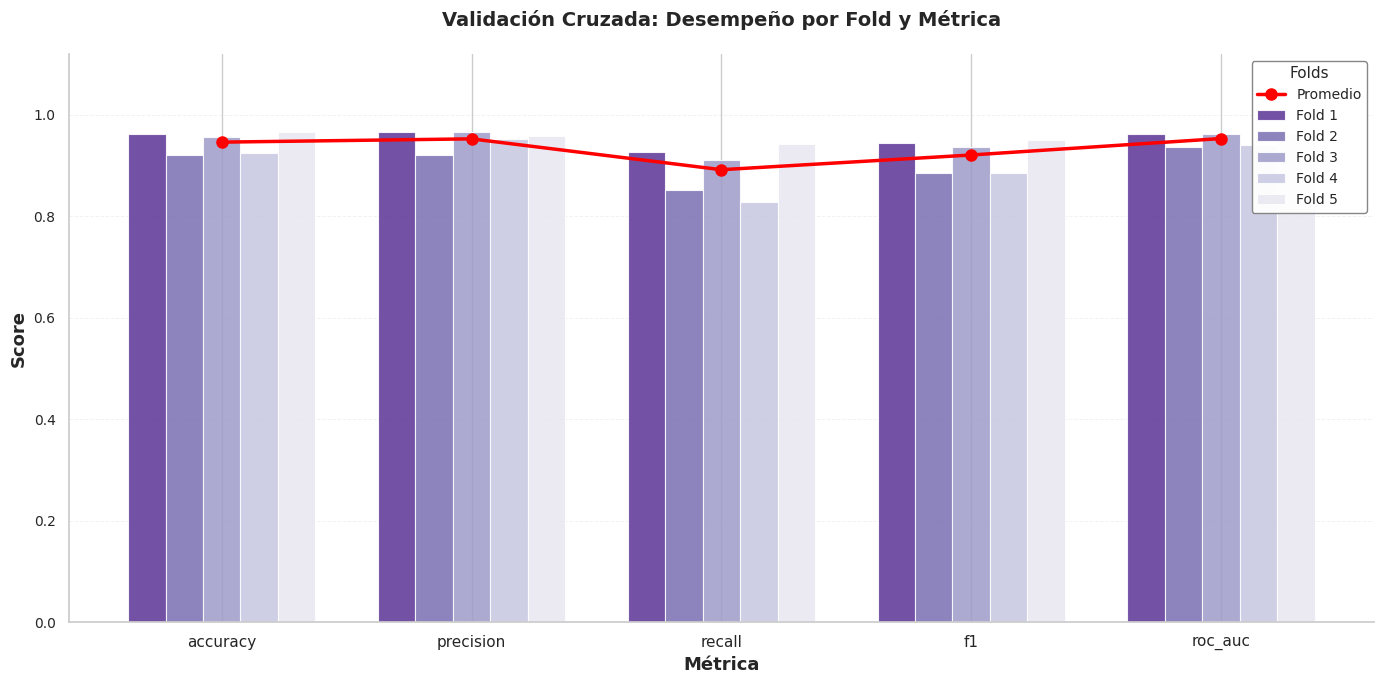

In [28]:
# Visualizar resultados de validación cruzada
# Las barras se muestran agrupadas por métrica (una al lado de otra para cada fold)
evaluation.plot_cross_validation_results(cv_results_rf)

### 6.5 Comparación Integrada: Regresión Logística vs Random Forest

En esta sección realizamos una comparación sistemática entre el modelo baseline (Regresión Logística) y el modelo avanzado (Random Forest). Utilizamos validación cruzada en el conjunto de entrenamiento y evaluación en el conjunto de prueba para obtener una visión integral del rendimiento.

**Pregunta de Investigación**: ¿Ofrece el modelo no-lineal (RF) una mejora significativa sobre el baseline interpretable (RL)?


In [29]:
# Comparar modelos: Regresión Logística vs Random Forest
models_to_compare = {
    'Regresión Logística': log_reg,
    'Random Forest': rf_model
}

print("Comparando modelos...")
comparison_results = evaluation.compare_models(
    models_to_compare,
    X_train_scaled,  # Para RL necesita datos escalados
    X_test_scaled,
    y_train,
    y_test,
    cv=5
)


Comparando modelos...

Evaluando: Regresión Logística

Test Set Performance:
  Accuracy: 0.8070
  Precision: 0.6825
  Recall: 0.8487
  F1-Score: 0.7566
  ROC AUC: 0.8837

Cross-Validation (Train Set):
  Accuracy CV: 0.8243 ± 0.0160
  ROC AUC CV: 0.9031 ± 0.0136

Evaluando: Random Forest

Test Set Performance:
  Accuracy: 0.9512
  Precision: 0.9456
  Recall: 0.9145
  F1-Score: 0.9298
  ROC AUC: 0.9420

Cross-Validation (Train Set):
  Accuracy CV: 0.9459 ± 0.0190
  ROC AUC CV: 0.9530 ± 0.0119


In [30]:
# Tabla comparativa
print("\n" + "="*120)
print("TABLA COMPARATIVA: LOGISTIC REGRESSION vs RANDOM FOREST")
print("="*120 + "\n")
comparison_table = evaluation.create_comparison_table(comparison_results)
display(comparison_table)

# Interpretar resultados
print("\n" + "="*120)
print("INTERPRETACIÓN")
print("="*120)
print("""
1. ACCURACY:
   - RL: Exactitud general (TP+TN)/(Total)
   - RF: Suele ser similar o mejor, especialmente si hay patrones no-lineales

2. PRECISION vs RECALL (Trade-off):
   - Precision: De los casos positivos predichos, ¿cuántos realmente lo son?
   - Recall: De los casos positivos reales, ¿cuántos detectamos?
   - En clínica, priorizamos RECALL (minimizar falsos negativos)

3. F1-SCORE:
   - Media armónica entre precision y recall
   - Buen balance general

4. ROC AUC:
   - Rendimiento a través de todos los umbrales
   - Menos sensible al desbalance de clases

5. CROSS-VALIDATION:
   - Estima el rendimiento real en datos nuevos
   - Desviación estándar indica consistencia del modelo
""")



TABLA COMPARATIVA: LOGISTIC REGRESSION vs RANDOM FOREST



,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,CV Accuracy,CV ROC AUC
0,Regresión Logística,0.8070,0.6825,0.8487,0.7566,0.8837,0.8243 ± 0.0160,0.9031 ± 0.0136
1,Random Forest,0.9512,0.9456,0.9145,0.9298,0.9420,0.9459 ± 0.0190,0.9530 ± 0.0119



INTERPRETACIÓN

1. ACCURACY:
   - RL: Exactitud general (TP+TN)/(Total)
   - RF: Suele ser similar o mejor, especialmente si hay patrones no-lineales

2. PRECISION vs RECALL (Trade-off):
   - Precision: De los casos positivos predichos, ¿cuántos realmente lo son?
   - Recall: De los casos positivos reales, ¿cuántos detectamos?
   - En clínica, priorizamos RECALL (minimizar falsos negativos)

3. F1-SCORE:
   - Media armónica entre precision y recall
   - Buen balance general

4. ROC AUC:
   - Rendimiento a través de todos los umbrales
   - Menos sensible al desbalance de clases

5. CROSS-VALIDATION:
   - Estima el rendimiento real en datos nuevos
   - Desviación estándar indica consistencia del modelo



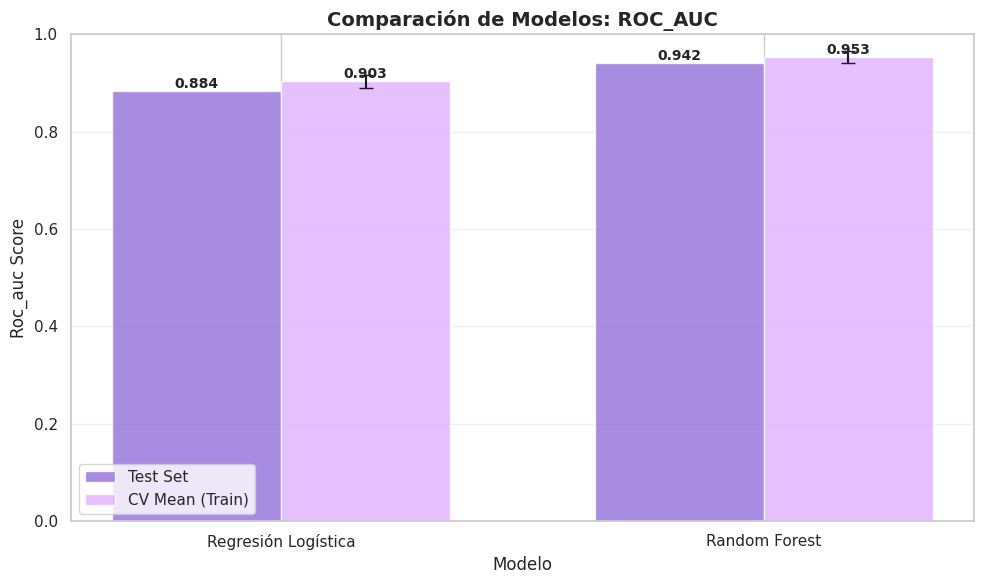

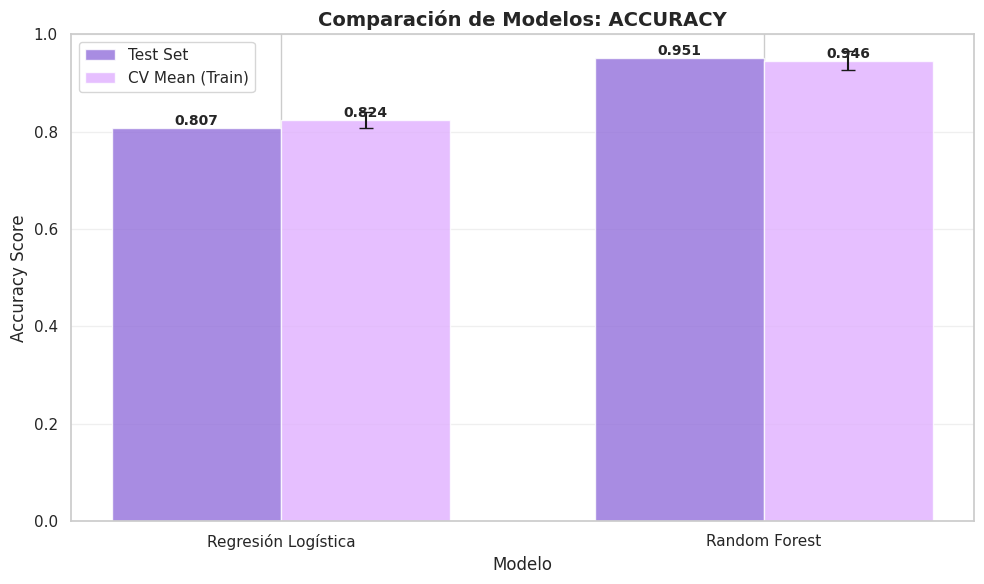

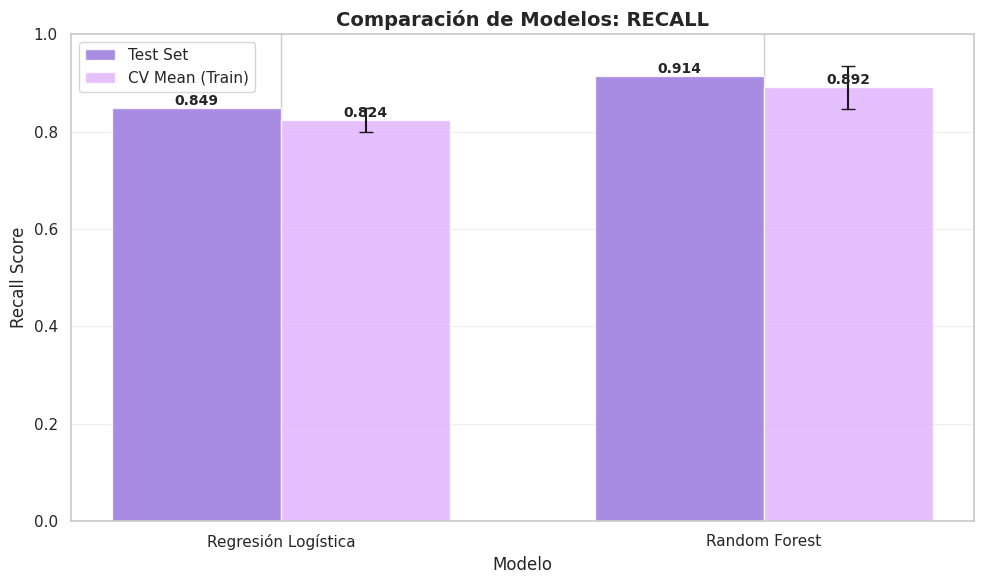

In [31]:
# Visualizar comparación: ROC AUC
evaluation.plot_model_comparison(comparison_results, metric='roc_auc')

# Visualizar comparación: Accuracy
evaluation.plot_model_comparison(comparison_results, metric='accuracy')

# Visualizar comparación: Recall (métrica clínica clave)
evaluation.plot_model_comparison(comparison_results, metric='recall')


### 6.6 Análisis Clínico de la Comparación

### Pregunta Fundamental para el Contexto Clínico

En un escenario de priorización de pacientes con **riesgo de Alzheimer**, ¿cuál es la métrica más importante?

**RECALL es crítica**: Minimizar falsos negativos (pacientes con Alzheimer que no detectamos) es más peligroso que falsos positivos (personas sin Alzheimer que derivamos para evaluación). Un paciente con Alzheimer no detectado no recibe atención temprana; un falso positivo apenas consume recursos de "evaluación adicional" en sistema de screening.

### Interpretación Clínica del Trade-off

- **Regresión Logística**: Resulta en un modelo **interpretable**, donde los coeficientes dicen "por cada unidad de MMSE, el log-odds de Alzheimer disminuye en X". Útil para clínicos.
  
- **Random Forest**: Modelo **flexible**, captura patrones complejos no lineales entre las variables, pero es una "caja negra". Con analisis de SHAP values ganamos poder de postexplicación.

### Decisión Clínica

La elección del modelo debe considerar:

1. **Recall superior** → Prioritizar el modelo que detecte más casos
2. **Interpretabilidad requerida** → Si clínicos necesitan entender decisiones
3. **Sobrecarga diagnosis falsa positiva** → Si el sistema tolera evaluaciones "innecesarias" (por trade-off precision-recall).
4. **Disponibilidad de especialistas** → Si hay recursos para evaluar más pacientes


## 7. Interpretabilidad — SHAP values

### 7.1 Motivación

Aunque el Random Forest mejora el desempeño predictivo, su naturaleza no lineal dificulta la interpretación directa. En un contexto *Healthcare*, no alcanza con predecir mejor: es necesario explicar por qué el modelo toma determinadas decisiones.

SHAP (SHapley Additive exPlanations) permite:

- Interpretabilidad global: qué variables impulsan el modelo en promedio.

- Interpretabilidad local: cómo contribuye cada variable a la predicción de un paciente individual.

- Comparabilidad clínica con el baseline lineal (RL).

### 7.2 Cálculo de valores SHAP

Se utiliza **TreeExplainer**, adecuado para modelos basados en árboles.

In [33]:
import shap

# Crear explainer SHAP para el modelo Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calcular valores SHAP
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Valores SHAP para la clase positiva (Alzheimer = 1)
shap_values_positive = shap_values[1]

print("Valores SHAP calculados correctamente.")
print(f"Forma de shap_values: {np.array(shap_values_positive).shape}")


/home/jgs/projects/alzheimer-risk-classification-ml/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Valores SHAP calculados correctamente.
Forma de shap_values: (28, 2)


### 7.3 Explicabilidad: Analisis SHAP

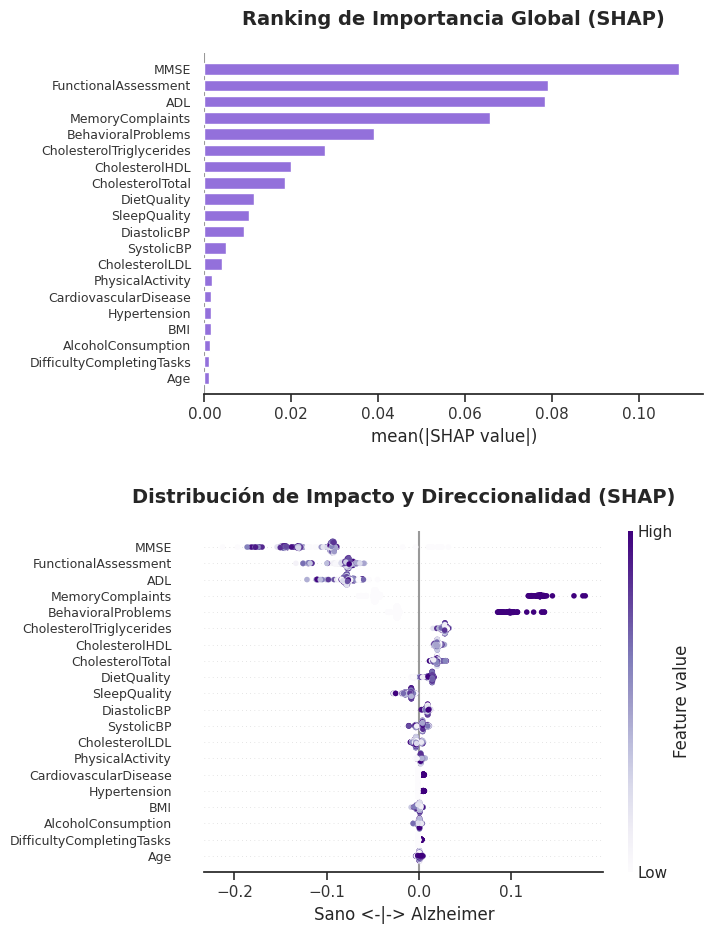

In [34]:
# Determinar el formato correcto de shap_values
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# Visualización SHAP
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# SHAP BAR PLOT
plt.sca(ax1)
shap.summary_plot(
    shap_values_to_plot,
    X_test,
    plot_type="bar",
    color='#9370DB',
    show=False
)
ax1.tick_params(axis='y', labelsize=9)
ax1.set_title("Ranking de Importancia Global (SHAP)", fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel("mean(|SHAP value|)", fontsize=12)

# SHAP BEE SWARM
plt.sca(ax2)
shap.summary_plot(
    shap_values_to_plot,
    X_test,
    show=False,
    cmap='Purples'
)
ax2.tick_params(axis='y', labelsize=9)
ax2.set_title("Distribución de Impacto y Direccionalidad (SHAP)", fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel("Sano <-|-> Alzheimer", fontsize=12)

plt.subplots_adjust(hspace=0.4)
plt.show()


El análisis SHAP muestra que:

- **Dominancia funcional**:
MMSE emerge como la variable más influyente del modelo, consolidándose como el principal motor de clasificación. FunctionalAssessment y ADL completan el podio de importancia, confirmando que el deterioro en la autonomía funcional es, junto con la cognición, el rasgo más distintivo para la detección de la enfermedad en este dataset.

- **Componente Conductual y Sintomático**:
MemoryComplaints y BehavioralProblems conforman el siguiente bloque de relevancia. Estas variables reflejan dominios clínicos clásicos, alineándose con la práctica médica y validando la consistencia de los hallazgos obtenidos en el baseline de Regresión Logística.

- **Contribución Vascular y Perfil Lipídico:**
Se observa una contribución leve pero consistente de variables como CholesterolTriglycerides, CholesterolHDL, CholesterolTotal. Aunque su impacto es menor comparado con los tests cognitivos, su presencia en el ranking es coherente con la conocida incidencia de los factores de riesgo vascular en la patogénesis y progresión del Alzheimer.

- **Baja Relevancia de Factores Periféricos**:
Variables como Age, DietQuality o BMI muestran un impacto marginal. Esto sugiere que, en este contexto de clasificación directa, los biomarcadores funcionales y cognitivos actuales opacan a los factores de riesgo epidemiológicos de largo plazo.

Respecto del impacto y la dirección:

- Observamos un **efecto protector** en MMSE, ADL y FA, donde valores altos se desplazan hacia la izquierda (valores SHAP negativos). Esto indica que un alto desempeño en estas áreas reduce significativamente el riesgo de Alzheimer.

- En cambio, MemoryComplaints y BehavioralProblems, la presencia del síntoma (valores altos) desplaza los puntos hacia la derecha, aumentando la probabilidad del diagnóstico positivo. Esto lo podemos considerar como **efecto de Riesgo**.

## 8. Conclusiones finales y aprendizajes del proyecto

### 8.1 Enfoque metodológico

Este proyecto presenta un flujo completo de **Machine Learning aplicado a Healthcare, con foco en clasificación predictiva interpretable para apoyar la priorización clínica de pacientes con riesgo de Alzheimer**.
A lo largo del análisis se priorizó:

- Claridad conceptual y trazabilidad clínica.
- Decisiones metodológicas justificadas.
- Reproducibilidad y buenas prácticas de modelado.

El EDA orientado a clínica permitió identificar variables con señal real y distinguirlas de aquellas potencialmente ruidosas, evitando ingeniería artificial o selección prematura.

### 8.2 Resultados clave y validación clínica

La comparación entre un baseline interpretable (Regresión Logística) y un modelo no lineal (Random Forest) mostró que:

- El **Random Forest** mejora métricas relevantes (recall y precision), evidenciando la presencia de relaciones no lineales.

- Ambos modelos coinciden en la jerarquía clínica de predictores.

- Las **variables funcionales y cognitivas** (FunctionalAssessment, ADL, MMSE) dominan la señal predictiva, mientras que síntomas inespecíficos y antecedentes generales aportan información marginal.

- El análisis de explicabilidad con **SHAP** confirmó que el modelo toma decisiones coherentes con el conocimiento clínico, reforzando su rol como herramienta de apoyo a la decisión.

### 8.3 Motivación personal y valor profesional del proyecto

Desarrollé este proyecto con el objetivo de consolidar y demostrar **competencias clave como científico de datos**, aplicando Machine Learning a un problema realista del dominio *Healthcare*. El foco estuvo puesto en construir modelos útiles, interpretables y metodológicamente sólidos, más que en maximizar métricas de forma artificial.

A lo largo del trabajo implementé un flujo profesional completo:
- EDA orientado a la pregunta clínica, definición de baselines interpretables (RL), comparación con modelos no lineales (RF) y validación mediante técnicas de explicabilidad (SHAP).
Este proyecto refleja habilidades centrales en ciencia de datos aplicada, incluyendo modelado supervisado, evaluación con métricas adecuadas, interpretación de modelos y comunicación técnica clara.

Mi objetivo es continuar desarrollándome como **Data Scientist**, participando en proyectos donde el rigor analítico, el contexto del problema y la toma de decisiones basada en datos sean fundamentales.

## 9. Apéndice

#### 9.1 Referencia del dataset

El dataset utilizado en este proyecto fue obtenido de Kaggle y debe ser citado de la siguiente manera:

Rabie El Kharoua (2024). Alzheimer's Disease Dataset.
Kaggle.
https://doi.org/10.34740/KAGGLE/DSV/8668279

#### 9.2 Consideraciones éticas y de uso de datos

El dataset es de acceso público y fue utilizado exclusivamente con fines educativos y demostrativos.

**No contiene información identificable de pacientes.**

El modelo desarrollado **no está destinado a uso clínico real**, diagnóstico ni toma de decisiones médicas directas.

El análisis se enmarca como ejercicio metodológico de **Machine Learning aplicado a salud**.

#### 9.3 Reproducibilidad

- Se fijaron semillas aleatorias para asegurar resultados reproducibles.

- El pipeline completo (EDA, preparación de datos, modelado y evaluación) se ejecuta de forma secuencial en un único notebook.

- Las librerías utilizadas pertenecen al ecosistema estándar de Python para ciencia de datos (pandas, numpy, scikit-learn, shap, matplotlib).

#### 9.4 Alcance del proyecto

Este notebook forma parte de un portfolio personal de proyectos en ciencia de datos, orientado a demostrar:

Capacidad analítica.

Criterio metodológico.

Comunicación técnica clara.

Aplicación responsable de Machine Learning en contextos de *Healthcare* y *Life Science*